In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [2]:
iso2 = 'SO'
iso3 = 'SOM'
to_crs = 'epsg:20539'
adm_level = 2

In [3]:
loaddir = '/data/big/fmalveiro/complexity72/'
savedir = '../../data/'

In [4]:
%%time
wb_gdf = gpd.read_file(os.path.join(loaddir, f"worldbankofficialboundaries-admin{adm_level}.geojson"))

CPU times: user 30.4 s, sys: 3.15 s, total: 33.5 s
Wall time: 34.9 s


In [5]:
loaddir = '/home/fmalveiro/extra/complexity72/climate-displacement/data/'

In [6]:
gadm_gdf = gpd.read_file(os.path.join(loaddir, f"gadm41_{iso3}_{adm_level}.json.zip"))

## Preprocessing
Filter the WorldBank dataframe only for the necessary entries.

In [7]:
wb_country = wb_gdf[wb_gdf['ISO_A2'] == iso2]

Project dataframes for upcoming distance comparison.

In [8]:
proj_gadm = gadm_gdf.to_crs(to_crs)
proj_wb = wb_country.to_crs(to_crs)

Obtain centroids to make distance comparison.

In [9]:
proj_gadm['centroid'] = proj_gadm.centroid
proj_wb['centroid'] = proj_wb.centroid

## Comparison

In [10]:
proj_gadm.shape

(74, 15)

In [11]:
proj_wb.shape

(74, 13)

In [12]:
gadm_feat = f"NAME_{adm_level}"
wb_feat = f"NAM_{adm_level}"

An auxiliary function for debugging purposes, fast computation of entries.

In [13]:
def compute(gadm_val, wb_val, gadm_feat='NAME_2', wb_feat='NAM_2'):
    return proj_gadm[proj_gadm[gadm_feat] == gadm_val]['centroid'].iloc[0].distance(
        proj_wb[proj_wb[wb_feat] == wb_val]['centroid'].iloc[0]
    )

Sort both dataframes by name to make them align rows.
- Keep the original index as a feature.
- **Beware**: row labels may differ from original data.

In [14]:
proj_gadm = proj_gadm.sort_values(gadm_feat).reset_index(drop=False)
proj_wb = proj_wb.sort_values(wb_feat).reset_index(drop=False)

Compute distance between centroids.

In [15]:
%%time
distances = proj_gadm['centroid'].apply(lambda x: proj_wb['centroid'].distance(x))

CPU times: user 14 ms, sys: 0 ns, total: 14 ms
Wall time: 13.5 ms


Note that the indices on the following dataframe correspond to the positions in which rows occur (`iloc`) on the *projected* dataframes, not row labels (`loc`).

In [16]:
distances

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,2116.212108,218158.574222,6.259904e+05,5.654053e+05,7.536228e+05,8.131390e+05,152298.073284,2.012669e+05,7.569114e+05,4.050092e+05,...,4.141391e+05,7.277160e+05,6.614829e+05,227730.183626,349324.472418,200685.763121,199981.304027,6.307998e+05,303754.936030,9.005160e+05
1,221120.954791,1884.812758,4.108526e+05,3.776437e+05,5.336600e+05,9.094370e+05,72456.210839,4.198751e+04,9.709714e+05,1.850275e+05,...,1.967800e+05,8.641931e+05,8.601319e+05,189173.932219,254777.472523,65737.466948,419823.756492,8.139627e+05,254389.711730,9.883692e+05
2,627472.473830,413100.215769,1.200164e+03,1.704308e+05,1.654011e+05,1.105699e+06,483836.238097,4.427325e+05,1.351636e+06,2.385273e+05,...,2.148570e+05,1.125468e+06,1.214618e+06,476353.083662,406313.761165,428534.957071,822920.425574,1.146658e+06,468194.905399,1.163264e+06
3,566524.102876,379229.875173,1.674656e+05,1.829967e+03,3.303402e+05,9.439033e+05,446171.341735,4.178811e+05,1.245186e+06,2.640783e+05,...,2.191030e+05,9.749779e+05,1.094246e+06,372809.991942,274559.669440,368316.770397,748856.719684,1.017623e+06,341488.481141,9.985551e+05
4,752832.620505,533592.743032,1.654866e+05,3.313297e+05,2.031154e+03,1.269963e+06,601695.518110,5.554804e+05,1.494185e+06,3.468943e+05,...,3.415935e+05,1.288270e+06,1.365213e+06,627132.381199,567171.659379,562154.744714,951364.969202,1.301594e+06,626907.540315,1.327017e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,201476.349760,64029.827087,4.274717e+05,3.674660e+05,5.635464e+05,8.447772e+05,90350.082373,9.490389e+04,9.331087e+05,2.216620e+05,...,2.202178e+05,8.028276e+05,8.133168e+05,124079.804401,200842.936353,571.399848,394737.368861,7.618955e+05,192015.082127,9.233672e+05
70,198179.545485,417391.488868,8.216599e+05,7.473669e+05,9.526654e+05,7.607288e+05,351338.401674,3.998455e+05,5.635688e+05,6.042575e+05,...,6.118381e+05,6.353604e+05,4.907513e+05,382567.077391,502016.744401,393884.798105,680.515302,4.834905e+05,442252.156497,8.523383e+05
71,627573.447499,810726.006185,1.143996e+06,1.014318e+06,1.301554e+06,4.338750e+05,764328.327532,8.118979e+05,3.118719e+05,9.794026e+05,...,9.676758e+05,2.465181e+05,1.132890e+05,673631.877706,743135.639583,759892.688705,481972.576093,1.763632e+03,678160.147804,5.148727e+05
72,303609.079081,253732.638058,4.664215e+05,3.391714e+05,6.276767e+05,6.798421e+05,272579.252791,2.870530e+05,9.056236e+05,3.429251e+05,...,3.151828e+05,6.678398e+05,7.540188e+05,80503.049324,66466.032044,191723.409371,443385.104682,6.805839e+05,872.467871,7.523106e+05


Text(0.5, 157.7222222222222, 'WB dataset')

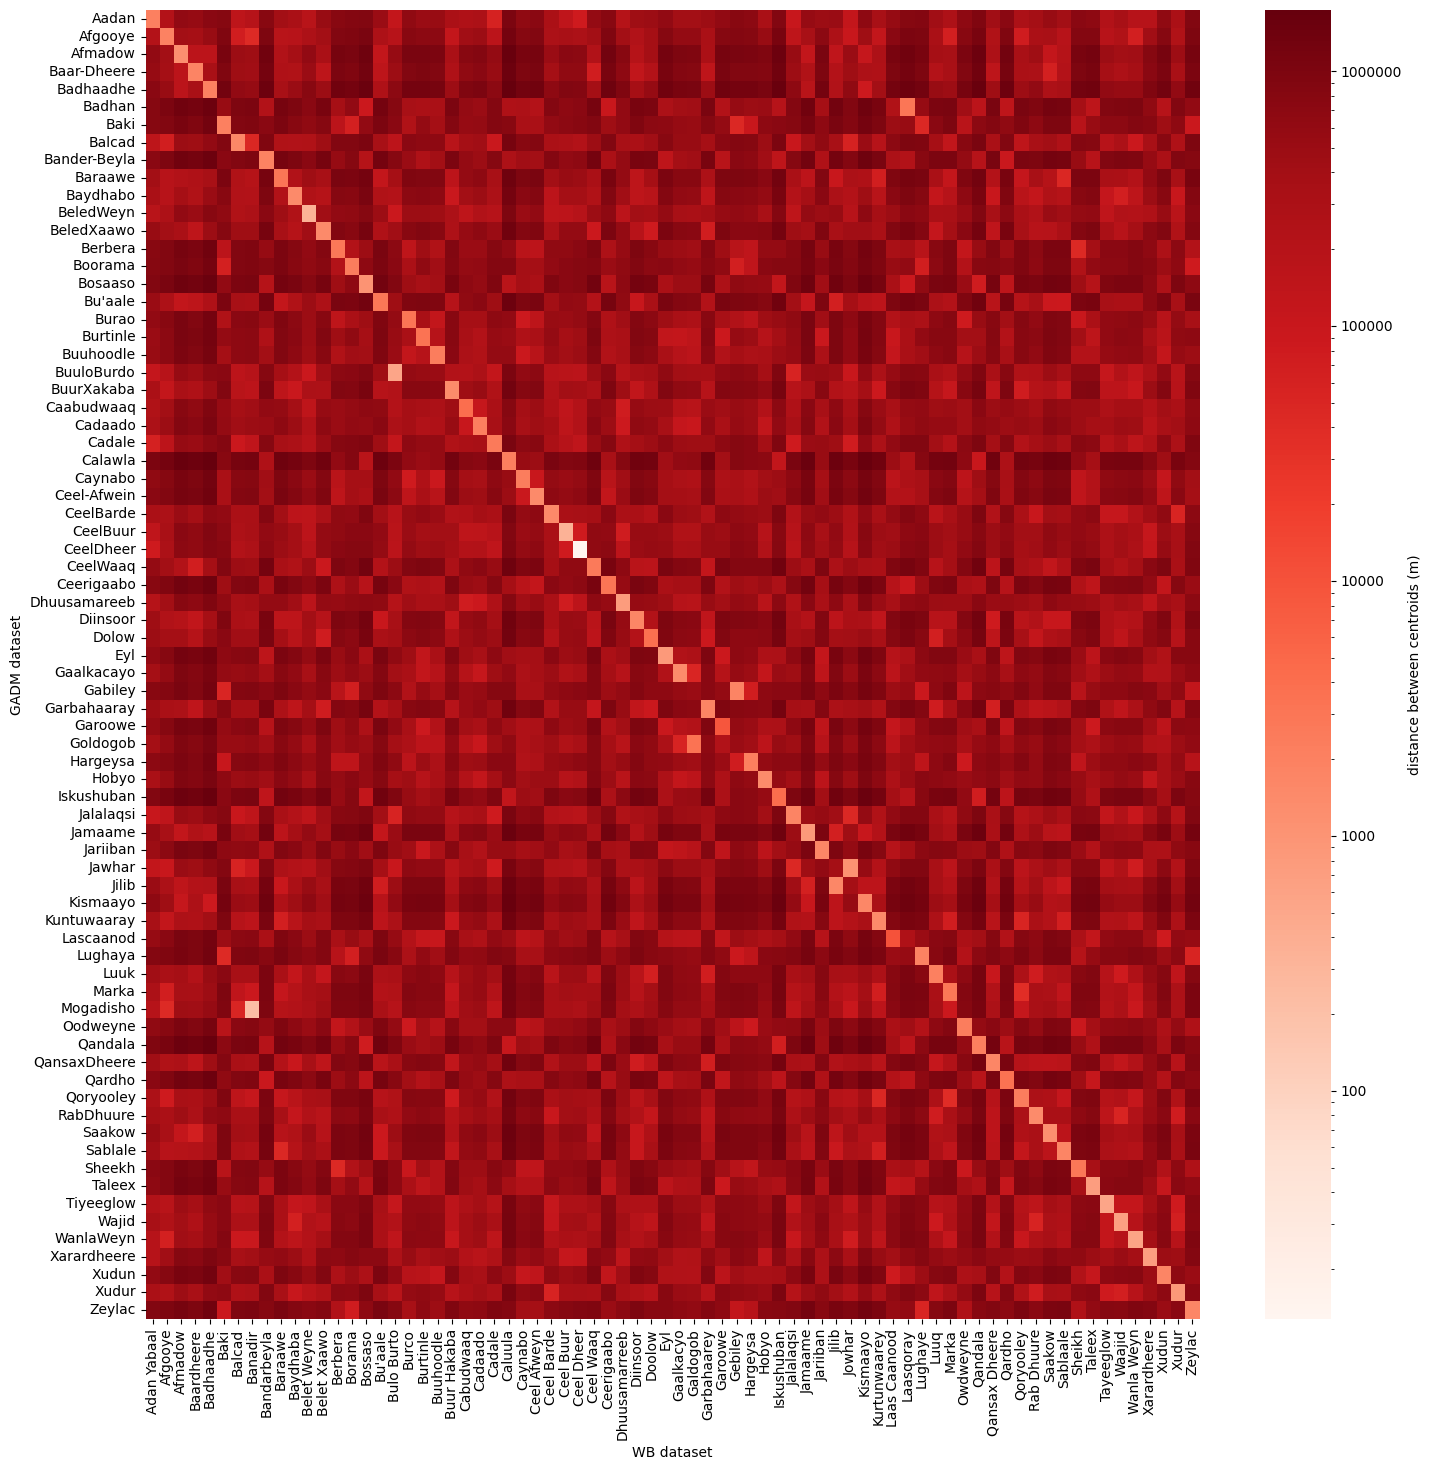

In [17]:
fig, ax = plt.subplots(1, figsize=(17,17))

sns.heatmap(distances, ax=ax, cmap='Reds', norm=mpl.colors.LogNorm(), cbar_kws={'label': 'distance between centroids (m)', 'format': '%2d'})

ax.set_yticks(ax.get_yticks(), labels=proj_gadm[gadm_feat], rotation=0)
ax.set_xticks(ax.get_xticks(), labels=proj_wb[wb_feat])

ax.set_ylabel('GADM dataset')
ax.set_xlabel('WB dataset')

Obtain the minimum distances.

In [18]:
closest = distances.apply(lambda x: x.argmin(), axis=1)

In [19]:
closest_dist = pd.Series({(idx1, idx2): distances[idx2][idx1] for idx1, idx2 in zip(range(proj_gadm.shape[0]), closest)}, name='closest')
closest_dist = closest_dist.rename_axis(('gadm_idx', 'wb_idx'))

In [20]:
sorted_dist = closest_dist.sort_values(ascending=True)

In [21]:
labels = sorted_dist.index.to_series().map(lambda x: f"({proj_gadm[gadm_feat][x[0]]}, {proj_wb[wb_feat][x[1]]})")

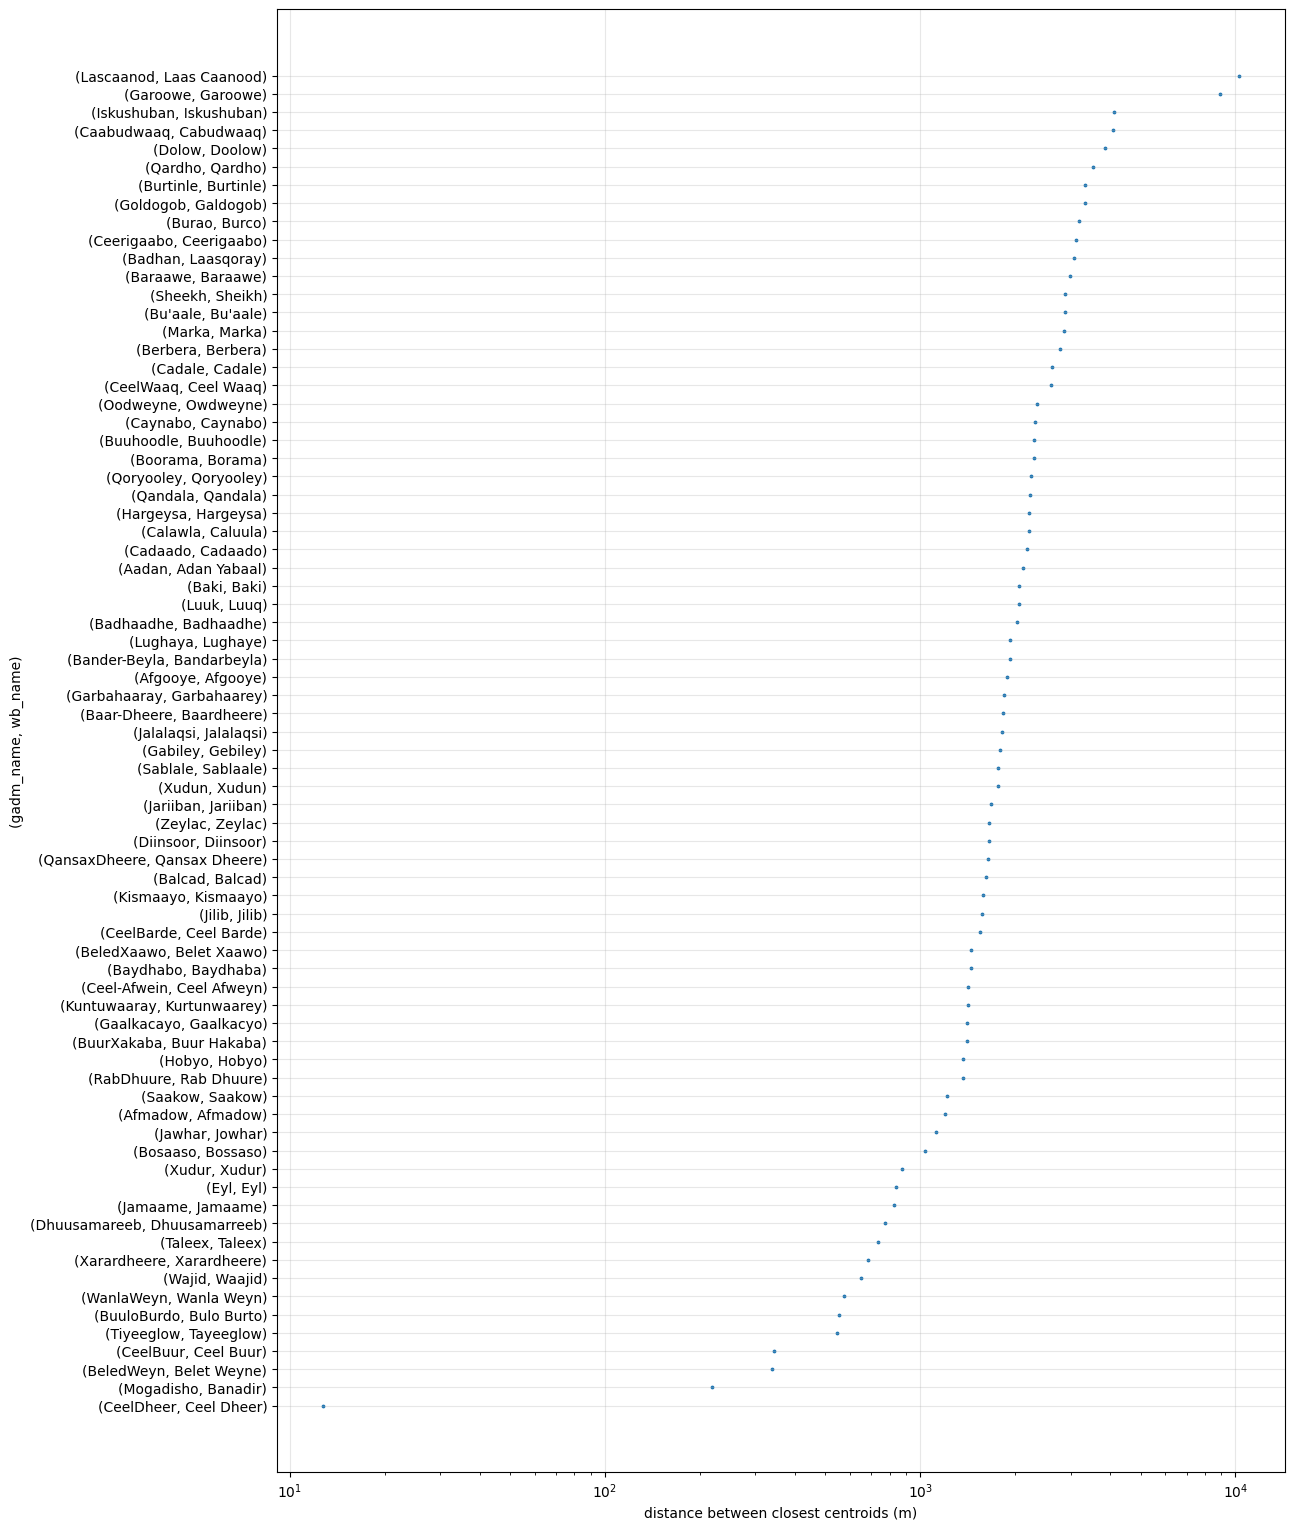

In [22]:
fig, ax = plt.subplots(1, figsize=(13,19))

ax.scatter(sorted_dist, range(proj_gadm.shape[0]), s=3)

ax.set_ylabel('(gadm_name, wb_name)')
ax.set_yticks(range(labels.size), labels=labels)

ax.set_xlabel('distance between closest centroids (m)')

ax.set_xscale('log')
ax.grid('on', alpha=.3)

In [23]:
mapping = labels.to_frame('pair').reset_index(drop=False)

mapping['centroid_dist'] = mapping['centroid_dist'] = labels.index.to_series().map(sorted_dist).reset_index(drop=True)

mapping['gadm_idx'] = mapping['gadm_idx'].map(lambda x: proj_gadm['index'][x])
mapping['wb_idx'] = mapping['wb_idx'].map(lambda x: proj_wb['index'][x])

mapping = pd.concat(
    (mapping, 
     pd.DataFrame.from_records(labels.apply(lambda x: x.strip('()').split(', ')).tolist(), columns=['gadm_name', 'wb_name'])
    ), axis=1
)

mapping = mapping.drop('pair', axis=1)

In [24]:
mapping

,gadm_idx,wb_idx,centroid_dist,gadm_name,wb_name
0,23,6541,12.733123,CeelDheer,Ceel Dheer
1,9,6531,218.439963,Mogadisho,Banadir
2,31,6545,338.590650,BeledWeyn,Belet Weyne
3,22,6540,344.519561,CeelBuur,Ceel Buur
4,6,6528,544.253658,Tiyeeglow,Tayeeglow
...,...,...,...,...,...
69,28,6543,3867.808257,Dolow,Doolow
70,20,6538,4079.400137,Caabudwaaq,Cabudwaaq
71,13,6535,4125.661361,Iskushuban,Iskushuban
72,48,6555,8962.639072,Garoowe,Garoowe


In [25]:
mapping.to_csv(os.path.join(savedir, 'region_mapping-gadm_wb-centroid.csv'), index=False)